# Few-Shot Learning using Prototypical Networks (ProtoNet)
This notebook trains and evaluates four architectures (CNN, CNN+Attention, CNN+Mamba, CNN+Attention+Mamba) on the HyperLeaf spectral dataset using Prototypical Networks.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("GPU configuration error:", e)

# Parameters
NUM_BANDS = 204
NUM_STATS = 5

# Load dataset
loaded_data = np.load("hyperleaf_processed.npz")
X_data = loaded_data['X']
y_data = loaded_data['y']

# Stratified train/val/test split
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Normalize data
X_min = X_train_raw.min()
X_max = X_train_raw.max()
X_train = (X_train_raw - X_min) / (X_max - X_min + 1e-8)
X_test = (X_test_raw - X_min) / (X_max - X_min + 1e-8)

# Function to sample episodic few-shot batches
def get_few_shot_episode(X, y, n_way=4, k_shot=10, q_query=5):
    unique_classes = np.unique(y)
    selected_classes = unique_classes[:n_way]
    support_x, support_y, query_x, query_y = [], [], [], []
    for label_idx, c in enumerate(selected_classes):
        class_indices = np.where(y == c)[0]
        sampled_indices = np.random.choice(class_indices, k_shot + q_query, replace=False)
        support_x.append(X[sampled_indices[:k_shot]])
        support_y.append(np.full((k_shot,), label_idx))
        query_x.append(X[sampled_indices[k_shot:]])
        query_y.append(np.full((q_query,), label_idx))
    support_x = np.concatenate(support_x, axis=0)
    support_y = np.concatenate(support_y, axis=0)
    query_x = np.concatenate(query_x, axis=0)
    query_y = np.concatenate(query_y, axis=0)
    shuffle_idx = np.random.permutation(len(query_y))
    query_x = query_x[shuffle_idx]
    query_y = query_y[shuffle_idx]
    return (tf.convert_to_tensor(support_x, dtype=tf.float32),
            tf.convert_to_tensor(support_y, dtype=tf.int32),
            tf.convert_to_tensor(query_x, dtype=tf.float32),
            tf.convert_to_tensor(query_y, dtype=tf.int32))

# Prototypical Network model class
class PrototypicalNetwork(tf.keras.Model):
    def __init__(self, encoder):
        super(PrototypicalNetwork, self).__init__()
        self.encoder = encoder
    def call(self, support_x, support_y, query_x, n_way, k_shot):
        support_embeddings = self.encoder(support_x, training=True)
        query_embeddings = self.encoder(query_x, training=True)
        d_dim = tf.shape(support_embeddings)[-1]
        support_reshaped = tf.reshape(support_embeddings, (n_way, k_shot, d_dim))
        prototypes = tf.reduce_mean(support_reshaped, axis=1)
        query_expanded = tf.expand_dims(query_embeddings, axis=1)
        proto_expanded = tf.expand_dims(prototypes, axis=0)
        distances = tf.reduce_sum(tf.square(query_expanded - proto_expanded), axis=-1)
        return -distances

def train_step_protonet(model, optimizer, support_x, support_y, query_x, query_y, n_way, k_shot):
    with tf.GradientTape() as tape:
        logits = model(support_x, support_y, query_x, n_way, k_shot)
        loss = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
            query_y, logits, from_logits=True
        ))
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    preds = tf.argmax(logits, axis=-1, output_type=tf.int32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(preds, query_y), tf.float32))
    return loss, accuracy

def train_protonet_model(encoder, episodes=4000, lr=2e-4):
    proto_net = PrototypicalNetwork(encoder)
    optimizer = tf.keras.optimizers.Adam(lr)
    loss_history, acc_history = [], []
    for ep in range(1, episodes + 1):
        sx, sy, qx, qy = get_few_shot_episode(X_train, y_train, 4, 5, 5)
        loss, acc = train_step_protonet(proto_net, optimizer, sx, sy, qx, qy, 4, 5)
        loss_history.append(loss.numpy())
        acc_history.append(acc.numpy())
        #if ep % 200 == 0:
        print(f"  Episode {ep:4d} | Loss: {loss:.4f} | Accuracy: {acc*100:.2f}%")
    return loss_history, acc_history


In [2]:
# --- 1. CNN Architecture ---
def build_cnn_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Encoder")

cnn_encoder = build_cnn_encoder()
print("Training CNN ProtoNet...")
loss_cnn, acc_cnn = train_protonet_model(cnn_encoder, episodes=4000)
cnn_encoder.save("best_protonet_cnn.keras")


Training CNN ProtoNet...
  Episode    1 | Loss: 1.3861 | Accuracy: 35.00%
  Episode    2 | Loss: 1.3706 | Accuracy: 45.00%
  Episode    3 | Loss: 1.3672 | Accuracy: 40.00%
  Episode    4 | Loss: 1.3130 | Accuracy: 45.00%
  Episode    5 | Loss: 1.3630 | Accuracy: 45.00%
  Episode    6 | Loss: 1.2778 | Accuracy: 55.00%
  Episode    7 | Loss: 1.3436 | Accuracy: 35.00%
  Episode    8 | Loss: 1.2515 | Accuracy: 55.00%
  Episode    9 | Loss: 1.1844 | Accuracy: 70.00%
  Episode   10 | Loss: 1.1305 | Accuracy: 50.00%
  Episode   11 | Loss: 1.2127 | Accuracy: 45.00%
  Episode   12 | Loss: 1.0937 | Accuracy: 60.00%
  Episode   13 | Loss: 1.0787 | Accuracy: 70.00%
  Episode   14 | Loss: 1.2230 | Accuracy: 30.00%
  Episode   15 | Loss: 1.1625 | Accuracy: 45.00%
  Episode   16 | Loss: 1.0625 | Accuracy: 60.00%
  Episode   17 | Loss: 1.1132 | Accuracy: 45.00%
  Episode   18 | Loss: 1.1080 | Accuracy: 50.00%
  Episode   19 | Loss: 0.9556 | Accuracy: 70.00%
  Episode   20 | Loss: 1.0355 | Accuracy: 70

In [3]:
# --- 2. CNN + Attention Architecture ---
def build_cnn_attention_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    
    # Attention block
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Encoder")

cnn_attention_encoder = build_cnn_attention_encoder()
print("Training CNN+Attention ProtoNet...")
loss_attention, acc_attention = train_protonet_model(cnn_attention_encoder, episodes=4000)
cnn_attention_encoder.save("best_protonet_cnn_attention.keras")


Training CNN+Attention ProtoNet...
  Episode    1 | Loss: 1.3574 | Accuracy: 45.00%
  Episode    2 | Loss: 1.3303 | Accuracy: 50.00%
  Episode    3 | Loss: 1.3630 | Accuracy: 30.00%
  Episode    4 | Loss: 1.3638 | Accuracy: 20.00%
  Episode    5 | Loss: 1.3398 | Accuracy: 45.00%
  Episode    6 | Loss: 1.3569 | Accuracy: 25.00%
  Episode    7 | Loss: 1.3742 | Accuracy: 35.00%
  Episode    8 | Loss: 1.3174 | Accuracy: 70.00%
  Episode    9 | Loss: 1.3344 | Accuracy: 45.00%
  Episode   10 | Loss: 1.2382 | Accuracy: 50.00%
  Episode   11 | Loss: 1.2378 | Accuracy: 55.00%
  Episode   12 | Loss: 1.1783 | Accuracy: 40.00%
  Episode   13 | Loss: 1.2178 | Accuracy: 55.00%
  Episode   14 | Loss: 1.0900 | Accuracy: 65.00%
  Episode   15 | Loss: 1.0385 | Accuracy: 75.00%
  Episode   16 | Loss: 1.1034 | Accuracy: 65.00%
  Episode   17 | Loss: 1.1757 | Accuracy: 45.00%
  Episode   18 | Loss: 1.1621 | Accuracy: 55.00%
  Episode   19 | Loss: 1.0414 | Accuracy: 65.00%
  Episode   20 | Loss: 1.0120 | Ac

In [4]:
# --- 3. CNN + Mamba Architecture ---
class StableMambaBlock(layers.Layer):
    def __init__(self, d_model, d_state=32, d_conv=4, expand=2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(expand * d_model)

    def build(self, input_shape):
        self.in_proj = layers.Dense(self.d_inner * 2, use_bias=False)
        self.conv1d = layers.Conv1D(
            filters=self.d_inner, kernel_size=self.d_conv, padding='same', groups=self.d_inner, activation='swish'
        )
        self.x_proj = layers.Dense(self.d_state * 2 + self.d_inner, use_bias=False)
        self.dt_proj = layers.Dense(self.d_inner, activation='softplus')
        
        A_init_val = -np.log(np.arange(1, self.d_state + 1, dtype=np.float32))
        A_init_val = np.tile(A_init_val[np.newaxis, :], (self.d_inner, 1))
        A_init = tf.keras.initializers.Constant(A_init_val)
        self.A = self.add_weight(
            name="A",
            shape=(self.d_inner, self.d_state),
            initializer=A_init,
            trainable=True
        )
        
        self.D = self.add_weight(
            name="D",
            shape=(self.d_inner,),
            initializer=tf.keras.initializers.Ones(),
            trainable=True
        )
        
        self.out_proj = layers.Dense(self.d_model, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        projected = self.in_proj(x)
        x_branch, res_branch = tf.split(projected, num_or_size_splits=2, axis=-1)
        x_branch = self.conv1d(x_branch)
        
        ssm_params = self.x_proj(x_branch)
        B, C, delta = tf.split(ssm_params, [self.d_state, self.d_state, self.d_inner], axis=-1)
        delta = self.dt_proj(delta)
        
        delta_expanded = tf.expand_dims(delta, axis=-1)
        A_expanded = tf.expand_dims(self.A, axis=0)
        A_expanded = tf.expand_dims(A_expanded, axis=0)
        
        A_bar = tf.exp(delta_expanded * A_expanded)
        
        B_expanded = tf.expand_dims(B, axis=2)
        B_bar = delta_expanded * B_expanded
        
        x_branch_expanded = tf.expand_dims(x_branch, axis=-1)
        inputs_ssm = B_bar * x_branch_expanded
        
        inputs_ssm = tf.transpose(inputs_ssm, perm=[1, 0, 2, 3])
        A_bar = tf.transpose(A_bar, perm=[1, 0, 2, 3])
        
        elems = (A_bar, inputs_ssm)
        batch_size = tf.shape(x)[0]
        h_0 = tf.zeros((batch_size, self.d_inner, self.d_state), dtype=tf.float32)
        
        def scan_fn(h_prev, elem):
            a_bar_t, ssm_in_t = elem
            return a_bar_t * h_prev + ssm_in_t
        
        h_seq = tf.scan(scan_fn, elems, initializer=h_0)
        h_seq = tf.transpose(h_seq, perm=[1, 0, 2, 3])
        
        C_expanded = tf.expand_dims(C, axis=2)
        y = tf.reduce_sum(h_seq * C_expanded, axis=-1)
        
        D_expanded = tf.reshape(self.D, (1, 1, self.d_inner))
        y = y + D_expanded * x_branch
        
        gated_output = y * tf.keras.activations.swish(res_branch)
        return self.out_proj(gated_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "d_state": self.d_state,
            "d_conv": self.d_conv,
            "expand": self.expand
        })
        return config

def build_cnn_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
   # x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Mamba_Encoder")

cnn_mamba_encoder = build_cnn_mamba_encoder()
print("Training CNN+Mamba ProtoNet...")
loss_mamba, acc_mamba = train_protonet_model(cnn_mamba_encoder, episodes=4000)
cnn_mamba_encoder.save("best_protonet_cnn_mamba.keras")


Training CNN+Mamba ProtoNet...
  Episode    1 | Loss: 1.3860 | Accuracy: 35.00%
  Episode    2 | Loss: 1.3842 | Accuracy: 55.00%
  Episode    3 | Loss: 1.3791 | Accuracy: 50.00%
  Episode    4 | Loss: 1.3724 | Accuracy: 40.00%
  Episode    5 | Loss: 1.3269 | Accuracy: 35.00%
  Episode    6 | Loss: 1.3229 | Accuracy: 50.00%
  Episode    7 | Loss: 1.2583 | Accuracy: 60.00%
  Episode    8 | Loss: 1.1742 | Accuracy: 60.00%
  Episode    9 | Loss: 1.1831 | Accuracy: 60.00%
  Episode   10 | Loss: 1.2792 | Accuracy: 70.00%
  Episode   11 | Loss: 1.2128 | Accuracy: 50.00%
  Episode   12 | Loss: 1.1513 | Accuracy: 45.00%
  Episode   13 | Loss: 1.4100 | Accuracy: 30.00%
  Episode   14 | Loss: 1.2193 | Accuracy: 45.00%
  Episode   15 | Loss: 1.2565 | Accuracy: 50.00%
  Episode   16 | Loss: 1.2689 | Accuracy: 40.00%
  Episode   17 | Loss: 1.1653 | Accuracy: 65.00%
  Episode   18 | Loss: 1.1782 | Accuracy: 45.00%
  Episode   19 | Loss: 1.1643 | Accuracy: 55.00%
  Episode   20 | Loss: 1.0605 | Accura

In [5]:
# --- 4. CNN + Attention + Mamba Architecture ---
def build_cnn_attention_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    #x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Mamba_Encoder")

cnn_attention_mamba_encoder = build_cnn_attention_mamba_encoder()
print("Training CNN+Attention+Mamba ProtoNet...")
loss_attn_mamba, acc_attn_mamba = train_protonet_model(cnn_attention_mamba_encoder, episodes=4000)
cnn_attention_mamba_encoder.save("best_protonet_cnn_attention_mamba.keras")


Training CNN+Attention+Mamba ProtoNet...
  Episode    1 | Loss: 1.3848 | Accuracy: 35.00%
  Episode    2 | Loss: 1.3791 | Accuracy: 50.00%
  Episode    3 | Loss: 1.3690 | Accuracy: 50.00%
  Episode    4 | Loss: 1.3749 | Accuracy: 30.00%
  Episode    5 | Loss: 1.3432 | Accuracy: 50.00%
  Episode    6 | Loss: 1.3582 | Accuracy: 45.00%
  Episode    7 | Loss: 1.2956 | Accuracy: 60.00%
  Episode    8 | Loss: 1.2725 | Accuracy: 50.00%
  Episode    9 | Loss: 1.2896 | Accuracy: 50.00%
  Episode   10 | Loss: 1.2359 | Accuracy: 50.00%
  Episode   11 | Loss: 1.3100 | Accuracy: 35.00%
  Episode   12 | Loss: 1.2723 | Accuracy: 55.00%
  Episode   13 | Loss: 1.2249 | Accuracy: 70.00%
  Episode   14 | Loss: 1.1862 | Accuracy: 45.00%
  Episode   15 | Loss: 1.1442 | Accuracy: 65.00%
  Episode   16 | Loss: 1.3732 | Accuracy: 25.00%
  Episode   17 | Loss: 1.2578 | Accuracy: 65.00%
  Episode   18 | Loss: 1.2879 | Accuracy: 60.00%
  Episode   19 | Loss: 1.2707 | Accuracy: 55.00%
  Episode   20 | Loss: 1.249

In [6]:
# --- 5. Testing Cell (Holdout Evaluation) ---
# 5-Shot Holdout Evaluation over 100 trials for each model
encoders = {
    'CNN': cnn_encoder,
    'CNN+Attention': cnn_attention_encoder,
    'CNN+Mamba': cnn_mamba_encoder,
    'CNN+Attention+Mamba': cnn_attention_mamba_encoder
}

eval_results = {}

for name, encoder in encoders.items():
    print(f"\nEvaluating {name} ProtoNet Encoder...")
    suffix = name.lower().replace('+', '_')
    try:
        encoder.load_weights(f"best_protonet_{suffix}.keras", by_name=True, skip_mismatch=True)
    except Exception as e:
        print(f"No saved weights found for {name}, using current weights.")
        
    trial_accs = []
    for i in range(100):
        # Sample test episode (5-shot, 5-query)
        sx, sy, qx, qy = get_few_shot_episode(X_test, y_test, 4, 5, 5)
        
        # Extract embeddings
        support_embeddings = encoder(sx, training=False)
        query_embeddings = encoder(qx, training=False)
        
        d_dim = tf.shape(support_embeddings)[-1]
        support_reshaped = tf.reshape(support_embeddings, (4, 5, d_dim))
        prototypes = tf.reduce_mean(support_reshaped, axis=1)
        
        query_expanded = tf.expand_dims(query_embeddings, axis=1)
        proto_expanded = tf.expand_dims(prototypes, axis=0)
        
        distances = tf.reduce_sum(tf.square(query_expanded - proto_expanded), axis=-1)
        preds = tf.argmax(-distances, axis=-1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, qy), tf.float32)).numpy()
        trial_accs.append(acc * 100.0)
        
    mean_acc = np.mean(trial_accs)
    max_acc = np.max(trial_accs)
    min_acc = np.min(trial_accs)
    eval_results[name] = trial_accs
    
    print(f"5-Shot Holdout Test Accuracy over 100 trials:")
    print(f"  Mean Accuracy: {mean_acc:.2f}%")
    print(f"  Max Accuracy:  {max_acc:.2f}%")
    print(f"  Min Accuracy:  {min_acc:.2f}%")



Evaluating CNN ProtoNet Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 60.50%
  Max Accuracy:  80.00%
  Min Accuracy:  35.00%

Evaluating CNN+Attention ProtoNet Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 87.05%
  Max Accuracy:  100.00%
  Min Accuracy:  65.00%

Evaluating CNN+Mamba ProtoNet Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 83.85%
  Max Accuracy:  100.00%
  Min Accuracy:  65.00%

Evaluating CNN+Attention+Mamba ProtoNet Encoder...
5-Shot Holdout Test Accuracy over 100 trials:
  Mean Accuracy: 46.15%
  Max Accuracy:  65.00%
  Min Accuracy:  30.00%


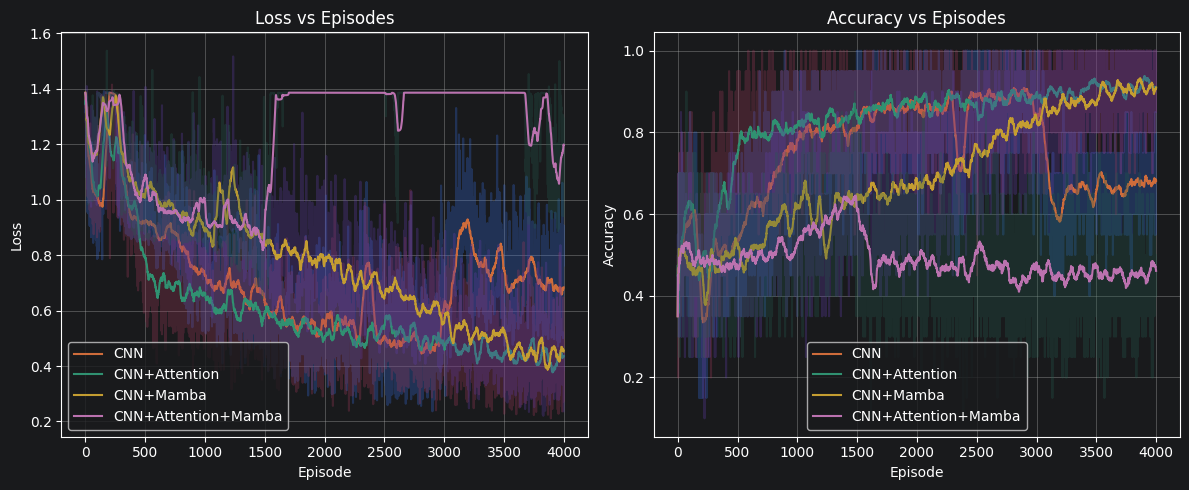

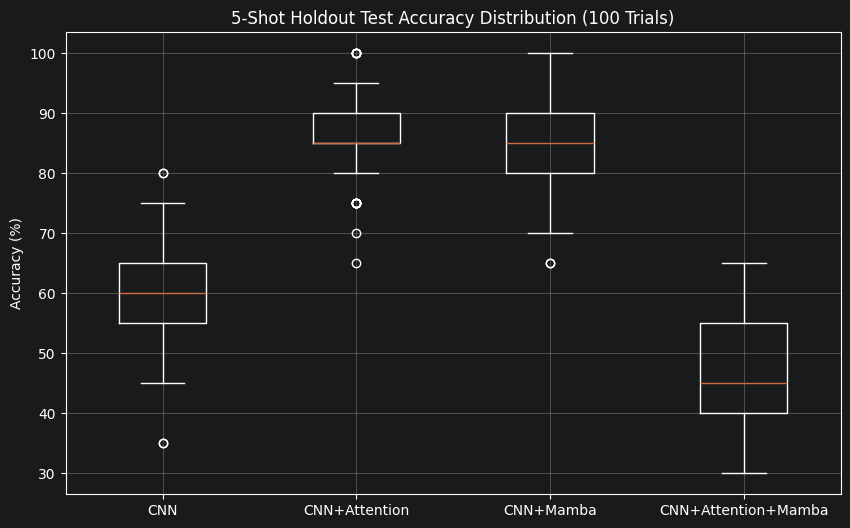

In [7]:
# --- 6. Plotting Cell ---
import pandas as pd
# Plotting training curves and evaluation results
histories = {
    'CNN': (loss_cnn, acc_cnn) if 'loss_cnn' in locals() else None,
    'CNN+Attention': (loss_attention, acc_attention) if 'loss_attention' in locals() else None,
    'CNN+Mamba': (loss_mamba, acc_mamba) if 'loss_mamba' in locals() else None,
    'CNN+Attention+Mamba': (loss_attn_mamba, acc_attn_mamba) if 'loss_attn_mamba' in locals() else None
}

def smooth(y, window=50):
    return pd.Series(y).rolling(window, min_periods=1).mean()

# 1. Loss vs Episode
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[0], alpha=0.3)
        plt.plot(smooth(hist[0]), label=f'{name}')
plt.title('Loss vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy vs Episode
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[1], alpha=0.3)
        plt.plot(smooth(hist[1]), label=f'{name}')
plt.title('Accuracy vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Holdout Evaluation Distributions
if eval_results:
    plt.figure(figsize=(10, 6))
    data_to_plot = [eval_results[name] for name in eval_results]
    plt.boxplot(data_to_plot, tick_labels=list(eval_results.keys()))
    plt.title('5-Shot Holdout Test Accuracy Distribution (100 Trials)')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.show()
